In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_groq import ChatGroq

from langchain.messages import RemoveMessage

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(model='llama-3.1-8b-instant')


In [4]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [6]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [7]:
graph = builder.compile(checkpointer=InMemorySaver())

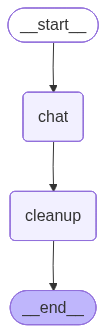

In [8]:
graph

In [9]:
config = {"configurable": {"thread_id": "t1"}}

In [10]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='699b97d6-fd0a-49bc-836f-7c5fbd905af0'),
  AIMessage(content="LangChain is an open-source framework for building large language models (LLMs) and other natural language processing (NLP) applications. It's a Python library that provides a set of tools and APIs for building, training, and deploying LLMs.\n\nLangChain is designed to make it easier to work with LLMs and other NLP models by providing a simple and intuitive API for tasks such as:\n\n1. **Model loading and management**: LangChain allows you to easily load and manage different LLM models, including pre-trained models and custom models you've trained yourself.\n2. **Text processing and analysis**: LangChain provides tools for text processing and analysis, such as tokenization, entity recognition, and sentiment analysis.\n3. **Model inference**: LangChain allows you to easily perform inference on your LLM models, including task

In [11]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
